In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/final_prepared.csv")

X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15967, 12)
Target shape: (15967,)


In [3]:
class LinearRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.w = None
        self.b = None
        self.loss_history = []

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for epoch in range(self.epochs):
            epoch_loss = 0
            indices = np.arange(m)
            np.random.shuffle(indices)

            # Split into mini-batches
            for start in range(0, m, self.batch_size):
                end = start + self.batch_size
                batch_idx = indices[start:end]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]

                y_pred = np.dot(X_batch, self.w) + self.b
                error = y_pred - y_batch

                dw = (2/self.batch_size) * np.dot(X_batch.T, error)
                db = (2/self.batch_size) * np.sum(error)

                self.w -= self.lr * dw
                self.b -= self.lr * db

                epoch_loss += np.mean(error**2)

            self.loss_history.append(epoch_loss)

    def mse(self, X, y):
        return np.mean((self.predict(X) - y)**2)

In [4]:
mb_model = LinearRegressionMiniBatch(learning_rate=0.01, epochs=50, batch_size=32)
mb_model.fit(X, y)

print("Final MSE:", mb_model.mse(X, y))

Final MSE: 4870838380.077226


In [5]:
import os
os.makedirs("../results", exist_ok=True)

np.save("../results/minibatch_loss.npy", mb_model.loss_history)
print("Loss history saved, length:", len(mb_model.loss_history))

Loss history saved, length: 50


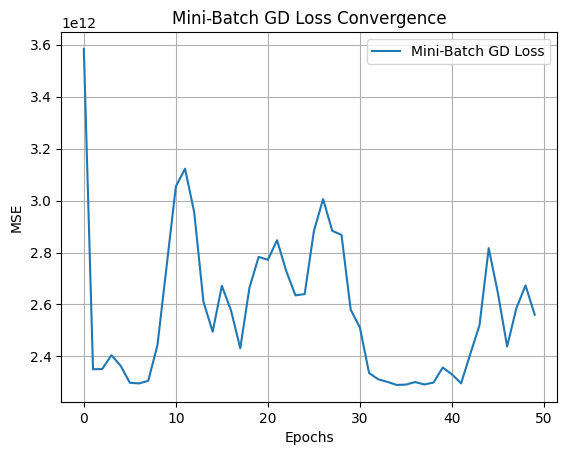

In [6]:
plt.plot(mb_model.loss_history, label="Mini-Batch GD Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Mini-Batch GD Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()